# BSD10k Confidence Filtering 분류기 v3

## 실험 진행 방식

이번 실험은 confidence를 1~5로 맞히는 문제가 아니라, BSD35k-CS에서 가져갈 만한 high-confidence sample을 고르는 filtering 문제로 재정의한다.

- target: `confidence >= 4`이면 1, 아니면 0
- 입력 feature: 이전 v2 실험의 `baseline` feature set 고정
- 모델: plain binary MLP 고정
- 검증: BSD10k 5-fold stratified OOF
- 모델 선택: OOF 기준 F1, AUC-PR
- threshold: 0.5 고정 금지, OOF probability에서 F1-optimal 및 precision-oriented threshold 탐색
- calibration: reliability diagram과 ECE 확인
- 비교 baseline: majority, random, 이전 5-class best `stage2_baseline_emd`의 score/probability를 binary로 변환
- 적용: fold ensemble로 BSD35k-CS에 probability를 예측하고 filtering CSV 저장

핵심 비교는 `5-class 학습 후 binary 변환`과 `처음부터 binary 학습` 중 어떤 쪽이 filtering에 더 좋은지 확인하는 것이다.


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import confidence_model_v2_experiments as v2

OUTPUT_DIR = ROOT / "outputs" / "confidence_filter_v3"
REPORT_DIR = OUTPUT_DIR / "reports"
PRED_DIR = OUTPUT_DIR / "predictions"
PLOT_DIR = OUTPUT_DIR / "plots"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
for path in [REPORT_DIR, PRED_DIR, PLOT_DIR, CHECKPOINT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
RUN_CONFIG = {
    "seed": SEED,
    "folds": 5,
    "epochs": 50,
    "patience": 7,
    "batch_size": 256,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "hidden": [512, 256],
    "feature_set": "baseline",
}
THRESHOLDS_TO_EVAL = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
DENSE_THRESHOLDS = np.round(np.linspace(0.05, 0.95, 181), 4)

print("root:", ROOT)
print("device:", DEVICE)


root: c:\Users\solok\Desktop\Dcase baseline
device: cuda


In [2]:
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def safe_auc_pr(y_true, score):
    try:
        return float(average_precision_score(y_true, score))
    except ValueError:
        return float("nan")


def safe_auc_roc(y_true, score):
    try:
        return float(roc_auc_score(y_true, score))
    except ValueError:
        return float("nan")


def metrics_from_pred_score(y_true, pred, score):
    return {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "auc_pr": safe_auc_pr(y_true, score),
        "auc_roc": safe_auc_roc(y_true, score),
    }


def metrics_at_threshold(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    out = metrics_from_pred_score(y_true, pred, prob)
    out["threshold"] = float(threshold)
    return out


def threshold_sweep(y_true, prob, thresholds):
    rows = []
    for threshold in thresholds:
        row = metrics_at_threshold(y_true, prob, threshold)
        rows.append({
            "threshold": row["threshold"],
            "accuracy": row["accuracy"],
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1"],
        })
    return pd.DataFrame(rows)


def expected_calibration_error(y_true, prob, n_bins=10):
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    ece = 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        if i == n_bins - 1:
            mask = (prob >= lo) & (prob <= hi)
        else:
            mask = (prob >= lo) & (prob < hi)
        n = int(mask.sum())
        if n == 0:
            rows.append({"bin": i, "lo": lo, "hi": hi, "n": 0, "mean_prob": np.nan, "actual_rate": np.nan, "gap": np.nan})
            continue
        mean_prob = float(prob[mask].mean())
        actual_rate = float(y_true[mask].mean())
        gap = abs(mean_prob - actual_rate)
        ece += (n / len(y_true)) * gap
        rows.append({"bin": i, "lo": lo, "hi": hi, "n": n, "mean_prob": mean_prob, "actual_rate": actual_rate, "gap": gap})
    return float(ece), pd.DataFrame(rows)


def align_by_sound_id(reference_df, prediction_path):
    pred_path = Path(prediction_path)
    if not pred_path.exists():
        return None
    pred = pd.read_csv(pred_path)
    pred["sound_id"] = pred["sound_id"].astype(str)
    ref = pd.DataFrame({"sound_id": reference_df["sound_id"].astype(str).to_numpy()})
    aligned = ref.merge(pred.drop_duplicates("sound_id"), on="sound_id", how="left")
    return aligned


def markdown_table(df, float_digits=4):
    view = df.copy()
    for col in view.columns:
        if pd.api.types.is_float_dtype(view[col]):
            view[col] = view[col].map(lambda x: "" if pd.isna(x) else f"{x:.{float_digits}f}")
    view = view.fillna("")
    headers = [str(col) for col in view.columns]
    rows = [[str(value) for value in row] for row in view.to_numpy()]
    widths = [max([len(headers[i])] + [len(row[i]) for row in rows]) for i in range(len(headers))]
    header = "| " + " | ".join(headers[i].ljust(widths[i]) for i in range(len(headers))) + " |"
    sep = "| " + " | ".join("-" * widths[i] for i in range(len(headers))) + " |"
    body = ["| " + " | ".join(row[i].ljust(widths[i]) for i in range(len(headers))) + " |" for row in rows]
    return "\n".join([header, sep] + body)


In [3]:
seed_everything(SEED)

parts, class_categories, top_class_categories = v2.load_bsd10k_parts()
bsd10k_df = parts["df"].copy()
y_conf = bsd10k_df["confidence"].to_numpy(dtype=np.int64)
y_binary = (y_conf >= 4).astype(np.int64)
x_raw = v2.matrix_for_feature_set(parts, RUN_CONFIG["feature_set"])

class_counts = pd.Series(y_conf).value_counts().sort_index().rename_axis("confidence").reset_index(name="n")
binary_counts = pd.Series(y_binary).map({0: "low_1to3", 1: "high_4to5"}).value_counts().rename_axis("target").reset_index(name="n")
binary_counts["ratio"] = binary_counts["n"] / len(y_binary)

print("BSD10k rows with embeddings:", len(bsd10k_df))
print("feature dim:", x_raw.shape[1])
display(class_counts)
display(binary_counts)

# Stage 0 baselines
baseline_rows = []
prior_high = float(y_binary.mean())
rng = np.random.default_rng(SEED)

majority_pred = np.ones_like(y_binary)
majority_score = np.ones_like(y_binary, dtype=np.float32) * prior_high
baseline_rows.append({"baseline": "Majority: all high", **metrics_from_pred_score(y_binary, majority_pred, majority_score)})

random_score = rng.random(len(y_binary))
random_pred = (rng.random(len(y_binary)) < prior_high).astype(int)
baseline_rows.append({"baseline": "Random: class prior", **metrics_from_pred_score(y_binary, random_pred, random_score)})

prev_oof = align_by_sound_id(bsd10k_df, ROOT / "outputs" / "confidence_model_v2" / "predictions" / "BSD10k_oof_predicted_v2.csv")
if prev_oof is not None and prev_oof["predicted_confidence_score"].notna().all():
    prev_score = prev_oof["predicted_confidence_score"].to_numpy(dtype=np.float32)
    prev_score_pred = (prev_score >= 4.0).astype(int)
    baseline_rows.append({"baseline": "Previous 5-class: score >= 4.0", **metrics_from_pred_score(y_binary, prev_score_pred, prev_score)})
    prev_prob_high = (prev_oof["prob_confidence_4"].to_numpy(dtype=np.float32) + prev_oof["prob_confidence_5"].to_numpy(dtype=np.float32))
    prev_prob_pred = (prev_prob_high >= 0.5).astype(int)
    baseline_rows.append({"baseline": "Previous 5-class: P4+P5 >= 0.5", **metrics_from_pred_score(y_binary, prev_prob_pred, prev_prob_high)})
else:
    print("Previous v2 OOF prediction file was not found or could not be aligned; previous 5-class baselines are skipped.")

stage0_baselines = pd.DataFrame(baseline_rows)
stage0_baselines.to_csv(REPORT_DIR / "stage0_baselines.csv", index=False)
display(stage0_baselines)


BSD10k rows with embeddings: 10956
feature dim: 1056


,confidence,n
0,1,106
1,2,749
2,3,3280
3,4,6045
4,5,776


,target,n,ratio
0,high_4to5,6821,0.622581
1,low_1to3,4135,0.377419


,baseline,accuracy,precision,recall,f1,auc_pr,auc_roc
0,Majority: all high,0.622581,0.622581,1.000000,0.767396,0.622581,0.500000
1,Random: class prior,0.525831,0.620982,0.611787,0.616350,0.620023,0.494324
2,Previous 5-class: score >= 4.0,0.513874,0.931831,0.236476,0.377222,0.837443,0.752323
3,Previous 5-class: P4+P5 >= 0.5,0.694323,0.723022,0.825099,0.770695,0.830483,0.748871


In [4]:
class BinaryConfidenceDataset(Dataset):
    def __init__(self, x, y=None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = None if y is None else torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        item = {"x": self.x[idx]}
        if self.y is not None:
            item["y"] = self.y[idx]
        return item


class BinaryConfidenceMLP(nn.Module):
    def __init__(self, input_dim, hidden=(512, 256), dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden[0]),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[0], hidden[1]),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden[1], 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def predict_binary_prob(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            x = batch["x"].to(DEVICE)
            probs.append(torch.sigmoid(model(x)).detach().cpu().numpy())
    return np.concatenate(probs).astype(np.float32)


def best_f1_threshold(y_true, prob, thresholds=DENSE_THRESHOLDS):
    sweep = threshold_sweep(y_true, prob, thresholds)
    return sweep.sort_values(["f1", "precision", "threshold"], ascending=[False, False, True]).iloc[0]


def train_one_fold_binary(fold, train_idx, valid_idx, x_raw, y_binary):
    seed_everything(SEED + fold)
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_raw[train_idx]).astype(np.float32)
    x_valid = scaler.transform(x_raw[valid_idx]).astype(np.float32)

    train_loader = DataLoader(
        BinaryConfidenceDataset(x_train, y_binary[train_idx]),
        batch_size=RUN_CONFIG["batch_size"],
        shuffle=True,
    )
    valid_loader = DataLoader(BinaryConfidenceDataset(x_valid), batch_size=RUN_CONFIG["batch_size"], shuffle=False)

    model = BinaryConfidenceMLP(
        x_raw.shape[1],
        hidden=tuple(RUN_CONFIG["hidden"]),
        dropout=RUN_CONFIG["dropout"],
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=RUN_CONFIG["learning_rate"],
        weight_decay=RUN_CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=RUN_CONFIG["epochs"])
    criterion = nn.BCEWithLogitsLoss()

    best_f1 = -1.0
    best_epoch = -1
    best_state = None
    stale_epochs = 0
    history = []

    for epoch in range(RUN_CONFIG["epochs"]):
        model.train()
        train_loss = 0.0
        seen = 0
        for batch in train_loader:
            x = batch["x"].to(DEVICE)
            y = batch["y"].to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += float(loss.item()) * x.shape[0]
            seen += x.shape[0]
        scheduler.step()

        valid_prob = predict_binary_prob(model, valid_loader)
        best_epoch_threshold = best_f1_threshold(y_binary[valid_idx], valid_prob)
        val_f1 = float(best_epoch_threshold["f1"])
        val_auc_pr = safe_auc_pr(y_binary[valid_idx], valid_prob)
        history.append({
            "epoch": epoch,
            "train_loss": train_loss / max(seen, 1),
            "val_f1_best_threshold": val_f1,
            "val_auc_pr": val_auc_pr,
            "best_epoch_threshold": float(best_epoch_threshold["threshold"]),
        })
        if val_f1 > best_f1 + 1e-6:
            best_f1 = val_f1
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= RUN_CONFIG["patience"]:
                break

    model.load_state_dict(best_state)
    valid_prob = predict_binary_prob(model, valid_loader)
    best_fold_threshold = best_f1_threshold(y_binary[valid_idx], valid_prob)
    fold_metrics = metrics_at_threshold(y_binary[valid_idx], valid_prob, float(best_fold_threshold["threshold"]))
    fold_metrics.update({
        "fold": fold,
        "best_epoch": int(best_epoch),
        "best_epoch_threshold": float(best_fold_threshold["threshold"]),
    })

    ckpt = {
        "model_state": best_state,
        "input_dim": int(x_raw.shape[1]),
        "scaler_mean": scaler.mean_.astype(np.float32),
        "scaler_scale": scaler.scale_.astype(np.float32),
        "feature_set": RUN_CONFIG["feature_set"],
        "best_epoch": int(best_epoch),
        "run_config": RUN_CONFIG,
    }
    torch.save(ckpt, CHECKPOINT_DIR / f"binary_mlp_fold_{fold}.pt")
    pd.DataFrame(history).to_csv(REPORT_DIR / f"binary_mlp_fold_{fold}_history.csv", index=False)
    return valid_prob, fold_metrics


splitter = StratifiedKFold(n_splits=RUN_CONFIG["folds"], shuffle=True, random_state=SEED)
splits = list(splitter.split(np.zeros(len(y_binary)), y_binary))

oof_prob = np.zeros(len(y_binary), dtype=np.float32)
fold_rows = []
start = time.time()
for fold, (train_idx, valid_idx) in enumerate(splits):
    valid_prob, fold_metrics = train_one_fold_binary(fold, train_idx, valid_idx, x_raw, y_binary)
    oof_prob[valid_idx] = valid_prob
    fold_rows.append(fold_metrics)
    print(f"fold={fold} f1={fold_metrics['f1']:.4f} auc_pr={fold_metrics['auc_pr']:.4f} threshold={fold_metrics['best_epoch_threshold']:.3f} epoch={fold_metrics['best_epoch']}")

fold_metrics_df = pd.DataFrame(fold_rows)
fold_metrics_df.to_csv(REPORT_DIR / "binary_mlp_fold_metrics.csv", index=False)

oof_out = bsd10k_df.copy()
oof_out["target_high_confidence"] = y_binary
oof_out["predicted_high_confidence_prob"] = oof_prob
oof_out.to_csv(PRED_DIR / "BSD10k_oof_binary_mlp.csv", index=False)

print("elapsed minutes:", (time.time() - start) / 60)
display(fold_metrics_df)


fold=0 f1=0.7930 auc_pr=0.8348 threshold=0.430 epoch=0
fold=1 f1=0.7815 auc_pr=0.8319 threshold=0.340 epoch=4
fold=2 f1=0.7823 auc_pr=0.8228 threshold=0.355 epoch=5
fold=3 f1=0.7854 auc_pr=0.8211 threshold=0.335 epoch=1
fold=4 f1=0.7897 auc_pr=0.8295 threshold=0.420 epoch=3
elapsed minutes: 2.3471364935239154


,accuracy,precision,recall,f1,auc_pr,auc_roc,threshold,fold,best_epoch,best_epoch_threshold
0,0.693887,0.684968,0.941392,0.792965,0.834818,0.757861,0.430,0,0,0.430
1,0.683706,0.685667,0.908358,0.781457,0.831888,0.751877,0.340,1,4,0.340
2,0.687357,0.690409,0.902493,0.782332,0.822793,0.735025,0.355,2,5,0.355
3,0.678229,0.671525,0.945748,0.785388,0.821143,0.740880,0.335,3,1,0.335
4,0.704245,0.708382,0.892229,0.789747,0.829465,0.755268,0.420,4,3,0.420


,threshold,accuracy,precision,recall,f1
0,0.30,0.663107,0.659922,0.946782,0.777744
1,0.35,0.676981,0.674835,0.928603,0.781638
2,0.40,0.687203,0.690417,0.902067,0.782178
3,0.45,0.694779,0.710447,0.860431,0.778279
4,0.50,0.700438,0.734278,0.813077,0.771671
5,0.55,0.696331,0.758508,0.751503,0.754989
6,0.60,0.680997,0.778746,0.681132,0.726676
7,0.65,0.664750,0.804331,0.609881,0.693738
8,0.70,0.642570,0.823713,0.541856,0.653696


,model,accuracy,precision,recall,f1,auc_pr,auc_roc,threshold
0,Binary MLP @ F1-optimal,0.687203,0.690417,0.902067,0.782178,0.825957,0.746148,0.400
1,Binary MLP @ precision-optimal recall>=0.7,0.684739,0.772279,0.700044,0.734389,0.825957,0.746148,0.585
2,Binary MLP @ threshold 0.5 reference,0.700438,0.734278,0.813077,0.771671,0.825957,0.746148,0.500


F1-optimal threshold: 0.4
Precision-optimal threshold @ recall>=0.7: 0.585


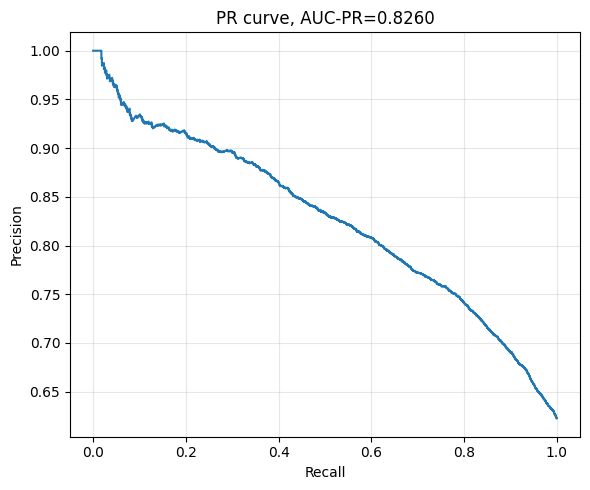

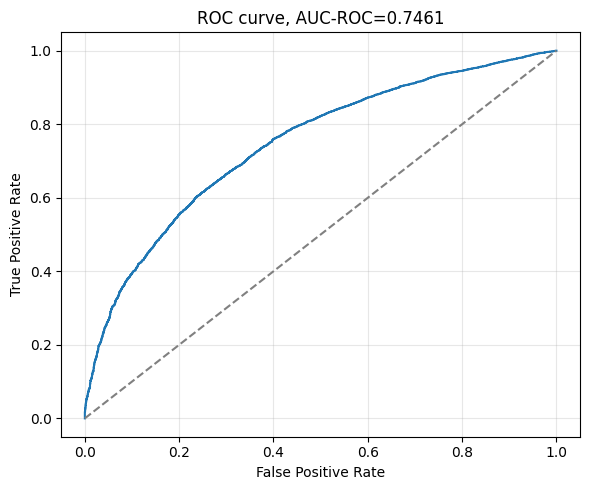

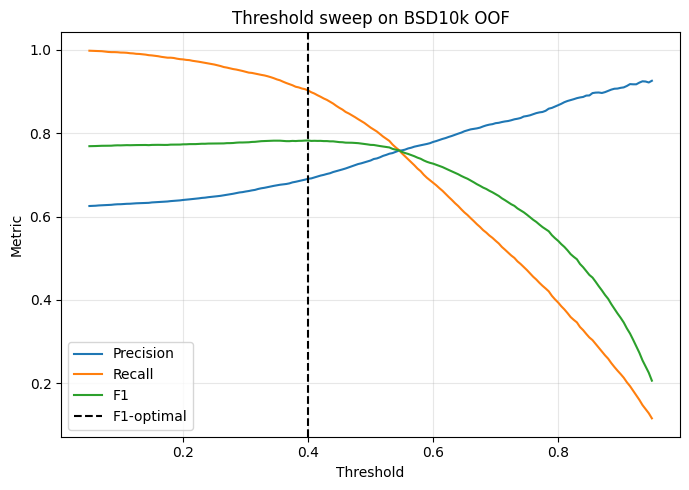

In [5]:
# Stage 2: OOF threshold tuning
fixed_threshold_sweep = threshold_sweep(y_binary, oof_prob, THRESHOLDS_TO_EVAL)
dense_threshold_sweep = threshold_sweep(y_binary, oof_prob, DENSE_THRESHOLDS)
f1_optimal = dense_threshold_sweep.sort_values(["f1", "precision", "threshold"], ascending=[False, False, True]).iloc[0]
precision_candidates = dense_threshold_sweep[dense_threshold_sweep["recall"] >= 0.7].copy()
precision_optimal_recall70 = precision_candidates.sort_values(["precision", "f1", "threshold"], ascending=[False, False, False]).iloc[0]

binary_mlp_oof_metrics = pd.DataFrame([
    {"model": "Binary MLP @ F1-optimal", **metrics_at_threshold(y_binary, oof_prob, float(f1_optimal["threshold"]))},
    {"model": "Binary MLP @ precision-optimal recall>=0.7", **metrics_at_threshold(y_binary, oof_prob, float(precision_optimal_recall70["threshold"]))},
    {"model": "Binary MLP @ threshold 0.5 reference", **metrics_at_threshold(y_binary, oof_prob, 0.5)},
])

fixed_threshold_sweep.to_csv(REPORT_DIR / "stage2_fixed_threshold_sweep.csv", index=False)
dense_threshold_sweep.to_csv(REPORT_DIR / "stage2_dense_threshold_sweep.csv", index=False)
binary_mlp_oof_metrics.to_csv(REPORT_DIR / "stage1_binary_mlp_oof_metrics.csv", index=False)

display(fixed_threshold_sweep)
display(binary_mlp_oof_metrics)
print("F1-optimal threshold:", float(f1_optimal["threshold"]))
print("Precision-optimal threshold @ recall>=0.7:", float(precision_optimal_recall70["threshold"]))

# Curves
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_binary, oof_prob)
fpr, tpr, roc_thresholds = roc_curve(y_binary, oof_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR curve, AUC-PR={safe_auc_pr(y_binary, oof_prob):.4f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "pr_curve.png", dpi=160)
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve, AUC-ROC={safe_auc_roc(y_binary, oof_prob):.4f}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "roc_curve.png", dpi=160)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(dense_threshold_sweep["threshold"], dense_threshold_sweep["precision"], label="Precision")
plt.plot(dense_threshold_sweep["threshold"], dense_threshold_sweep["recall"], label="Recall")
plt.plot(dense_threshold_sweep["threshold"], dense_threshold_sweep["f1"], label="F1")
plt.axvline(float(f1_optimal["threshold"]), linestyle="--", color="black", label="F1-optimal")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.title("Threshold sweep on BSD10k OOF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "threshold_sweep.png", dpi=160)
plt.show()


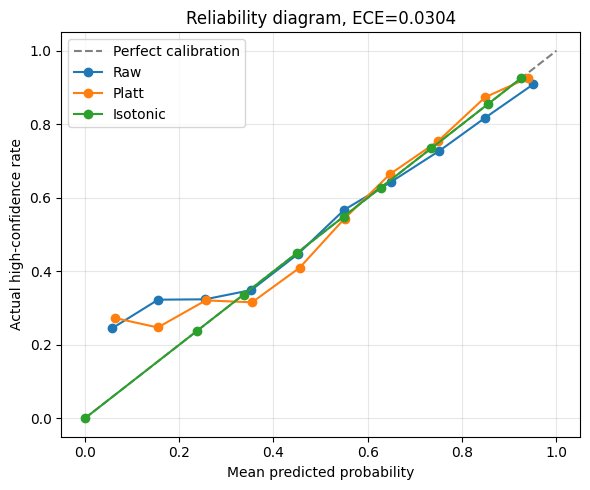

,model,ece_10bins,note
0,Binary MLP raw probability,3.038598e-02,export probability uses this raw score
1,Platt scaling on OOF,2.338292e-02,diagnostic calibration candidate
2,Isotonic regression on OOF,1.125612e-08,diagnostic calibration candidate; can overfit


,bin,lo,hi,n,mean_prob,actual_rate,gap
0,0,0.0,0.1,196,0.057741,0.244898,0.187157
1,1,0.1,0.2,347,0.155366,0.322767,0.167401
2,2,0.2,0.3,627,0.255000,0.323764,0.068764
3,3,0.3,0.4,874,0.353063,0.348970,0.004093
4,4,0.4,0.5,1359,0.451627,0.446652,0.004976
5,5,0.5,0.6,1587,0.549904,0.567108,0.017204
6,6,0.6,0.7,1479,0.648223,0.642326,0.005897
7,7,0.7,0.8,1387,0.751540,0.727469,0.024070
8,8,0.8,0.9,1430,0.849494,0.818182,0.031312
9,9,0.9,1.0,1670,0.950597,0.908383,0.042214


In [6]:
# Stage 3: calibration check
# Platt/isotonic are fitted on OOF predictions only. This is useful as a calibration diagnostic,
# but use a separate calibration split if you need a fully unbiased calibration estimate.
ece, calibration_bins = expected_calibration_error(y_binary, oof_prob, n_bins=10)

eps = 1e-6
oof_prob_clipped = np.clip(oof_prob, eps, 1.0 - eps)
oof_logit = np.log(oof_prob_clipped / (1.0 - oof_prob_clipped)).reshape(-1, 1)

platt_model = LogisticRegression(solver="lbfgs", max_iter=1000)
platt_model.fit(oof_logit, y_binary)
platt_prob = platt_model.predict_proba(oof_logit)[:, 1].astype(np.float32)
platt_ece, platt_bins = expected_calibration_error(y_binary, platt_prob, n_bins=10)

isotonic_model = IsotonicRegression(out_of_bounds="clip")
isotonic_model.fit(oof_prob, y_binary)
isotonic_prob = isotonic_model.predict(oof_prob).astype(np.float32)
isotonic_ece, isotonic_bins = expected_calibration_error(y_binary, isotonic_prob, n_bins=10)

calibration_bins.to_csv(REPORT_DIR / "stage3_calibration_bins_raw.csv", index=False)
platt_bins.to_csv(REPORT_DIR / "stage3_calibration_bins_platt.csv", index=False)
isotonic_bins.to_csv(REPORT_DIR / "stage3_calibration_bins_isotonic.csv", index=False)

plt.figure(figsize=(6, 5))
valid_bins = calibration_bins.dropna(subset=["mean_prob", "actual_rate"])
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
plt.plot(valid_bins["mean_prob"], valid_bins["actual_rate"], marker="o", label="Raw")
for label, bins in [("Platt", platt_bins), ("Isotonic", isotonic_bins)]:
    vb = bins.dropna(subset=["mean_prob", "actual_rate"])
    plt.plot(vb["mean_prob"], vb["actual_rate"], marker="o", label=label)
plt.xlabel("Mean predicted probability")
plt.ylabel("Actual high-confidence rate")
plt.title(f"Reliability diagram, ECE={ece:.4f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "reliability_diagram.png", dpi=160)
plt.show()

calibration_summary = pd.DataFrame([
    {"model": "Binary MLP raw probability", "ece_10bins": ece, "note": "export probability uses this raw score"},
    {"model": "Platt scaling on OOF", "ece_10bins": platt_ece, "note": "diagnostic calibration candidate"},
    {"model": "Isotonic regression on OOF", "ece_10bins": isotonic_ece, "note": "diagnostic calibration candidate; can overfit"},
])
calibration_summary.to_csv(REPORT_DIR / "stage3_calibration_summary.csv", index=False)
display(calibration_summary)
display(calibration_bins)


In [7]:
# Stage 5: previous 5-class vs binary MLP direct comparison
comparison_rows = []
if prev_oof is not None and prev_oof["predicted_confidence_score"].notna().all():
    prev_score = prev_oof["predicted_confidence_score"].to_numpy(dtype=np.float32)
    prev_prob_high = (prev_oof["prob_confidence_4"].to_numpy(dtype=np.float32) + prev_oof["prob_confidence_5"].to_numpy(dtype=np.float32))
    comparison_rows.append({
        "method": "5-class previous best",
        "binary_conversion": "predicted_score >= 4.0",
        **metrics_from_pred_score(y_binary, (prev_score >= 4.0).astype(int), prev_score),
    })
    comparison_rows.append({
        "method": "5-class previous best",
        "binary_conversion": "P(c=4)+P(c=5) >= 0.5",
        **metrics_from_pred_score(y_binary, (prev_prob_high >= 0.5).astype(int), prev_prob_high),
    })

comparison_rows.append({
    "method": "Binary MLP v3",
    "binary_conversion": f"prob >= F1-optimal ({float(f1_optimal['threshold']):.3f})",
    **metrics_at_threshold(y_binary, oof_prob, float(f1_optimal["threshold"])),
})

stage5_comparison = pd.DataFrame(comparison_rows)
stage5_comparison.to_csv(REPORT_DIR / "stage5_5class_vs_binary_comparison.csv", index=False)
display(stage5_comparison)


,method,binary_conversion,accuracy,precision,recall,f1,auc_pr,auc_roc,threshold
0,5-class previous best,predicted_score >= 4.0,0.513874,0.931831,0.236476,0.377222,0.837443,0.752323,NaN
1,5-class previous best,P(c=4)+P(c=5) >= 0.5,0.694323,0.723022,0.825099,0.770695,0.830483,0.748871,NaN
2,Binary MLP v3,prob >= F1-optimal (0.400),0.687203,0.690417,0.902067,0.782178,0.825957,0.746148,0.4


In [8]:
# Stage 6: apply fold ensemble to BSD35k-CS
def load_binary_fold_models():
    artifacts = []
    for ckpt_path in sorted(CHECKPOINT_DIR.glob("binary_mlp_fold_*.pt")):
        try:
            ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        except TypeError:
            ckpt = torch.load(ckpt_path, map_location="cpu")
        model = BinaryConfidenceMLP(
            ckpt["input_dim"],
            hidden=tuple(ckpt["run_config"]["hidden"]),
            dropout=ckpt["run_config"]["dropout"],
        ).to(DEVICE)
        model.load_state_dict(ckpt["model_state"])
        scaler = StandardScaler()
        scaler.mean_ = ckpt["scaler_mean"].astype(np.float64)
        scaler.scale_ = ckpt["scaler_scale"].astype(np.float64)
        scaler.var_ = scaler.scale_ ** 2
        scaler.n_features_in_ = ckpt["input_dim"]
        artifacts.append((model, scaler, ckpt))
    if not artifacts:
        raise FileNotFoundError("No binary fold checkpoints found. Run the CV training cell first.")
    return artifacts


def predict_with_fold_ensemble(parts_to_predict):
    x_to_predict_raw = v2.matrix_for_feature_set(parts_to_predict, RUN_CONFIG["feature_set"])
    fold_probs = []
    for model, scaler, ckpt in load_binary_fold_models():
        x_scaled = scaler.transform(x_to_predict_raw).astype(np.float32)
        loader = DataLoader(BinaryConfidenceDataset(x_scaled), batch_size=RUN_CONFIG["batch_size"], shuffle=False)
        fold_probs.append(predict_binary_prob(model, loader))
    return np.vstack(fold_probs).mean(axis=0).astype(np.float32)


bsd35k_parts = v2.load_bsd35k_parts(class_categories, top_class_categories, parts)
bsd35k_df = bsd35k_parts["df"].copy()
bsd35k_prob = predict_with_fold_ensemble(bsd35k_parts)

f1_threshold = float(f1_optimal["threshold"])
precision_threshold = float(precision_optimal_recall70["threshold"])

scenario_thresholds = [
    ("default_0.5", 0.5),
    ("f1_optimal", f1_threshold),
    ("precision_optimal_recall70", precision_threshold),
    ("strict_0.7", 0.7),
    ("very_strict_0.8", 0.8),
    ("ultra_strict_0.9", 0.9),
]

scenario_rows = []
for name, threshold in scenario_thresholds:
    kept = int((bsd35k_prob >= threshold).sum())
    oof_m = metrics_at_threshold(y_binary, oof_prob, threshold)
    scenario_rows.append({
        "scenario": name,
        "threshold": threshold,
        "retained_samples": kept,
        "retained_ratio": kept / len(bsd35k_prob),
        "expected_precision_from_oof": oof_m["precision"],
        "expected_recall_from_oof": oof_m["recall"],
        "expected_f1_from_oof": oof_m["f1"],
    })
filtering_scenarios = pd.DataFrame(scenario_rows)
filtering_scenarios.to_csv(REPORT_DIR / "stage4_bsd35k_filtering_scenarios.csv", index=False)

prev_bsd35k = align_by_sound_id(bsd35k_df, ROOT / "outputs" / "confidence_model_v2" / "predictions" / "BSD35k-CS_predicted_v2.csv")

pred_out = bsd35k_df.copy()
pred_out["sample_id"] = pred_out["sound_id"].astype(str)
pred_out["predicted_high_confidence_prob"] = bsd35k_prob
pred_out["predicted_high_confidence"] = (bsd35k_prob >= f1_threshold).astype(int)
pred_out["predicted_high_confidence_precision_recall70"] = (bsd35k_prob >= precision_threshold).astype(int)
pred_out["predicted_high_confidence_strict"] = (bsd35k_prob >= 0.7).astype(int)
pred_out["predicted_high_confidence_ultra"] = (bsd35k_prob >= 0.9).astype(int)
pred_out["binary_f1_optimal_threshold"] = f1_threshold
pred_out["binary_precision_optimal_recall70_threshold"] = precision_threshold

if prev_bsd35k is not None and prev_bsd35k["predicted_confidence_score"].notna().all():
    pred_out["previous_5class_predicted_confidence_score"] = prev_bsd35k["predicted_confidence_score"].to_numpy(dtype=np.float32)
    pred_out["previous_5class_prob_high_p4_p5"] = (
        prev_bsd35k["prob_confidence_4"].to_numpy(dtype=np.float32) + prev_bsd35k["prob_confidence_5"].to_numpy(dtype=np.float32)
    )

export_cols = [
    "sample_id",
    "sound_id",
    "class",
    "class_idx",
    "class_top",
    "uploader",
    "title",
    "tags",
    "description",
    "predicted_high_confidence_prob",
    "predicted_high_confidence",
    "predicted_high_confidence_precision_recall70",
    "predicted_high_confidence_strict",
    "predicted_high_confidence_ultra",
    "binary_f1_optimal_threshold",
    "binary_precision_optimal_recall70_threshold",
]
optional_cols = ["previous_5class_predicted_confidence_score", "previous_5class_prob_high_p4_p5"]
export_cols += [col for col in optional_cols if col in pred_out.columns]
pred_out[export_cols].to_csv(PRED_DIR / "BSD35k-CS_filter_predictions.csv", index=False)

display(filtering_scenarios)
print("saved:", PRED_DIR / "BSD35k-CS_filter_predictions.csv")


,scenario,threshold,retained_samples,retained_ratio,expected_precision_from_oof,expected_recall_from_oof,expected_f1_from_oof
0,default_0.5,0.500,19811,0.629640,0.734278,0.813077,0.771671
1,f1_optimal,0.400,25945,0.824593,0.690417,0.902067,0.782178
2,precision_optimal_recall70,0.585,13715,0.435895,0.772279,0.700044,0.734389
3,strict_0.7,0.700,7033,0.223525,0.823713,0.541856,0.653696
4,very_strict_0.8,0.800,2997,0.095252,0.866774,0.393931,0.541679
5,ultra_strict_0.9,0.900,670,0.021294,0.908383,0.222401,0.357320


saved: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_filter_v3\predictions\BSD35k-CS_filter_predictions.csv


In [9]:
# Final report
report_lines = [
    "# BSD10k Confidence Filtering 분류기 v3 보고서",
    "",
    "## 1. Task 재정의",
    "",
    "기존 1~5 ordinal confidence 예측을 BSD35k-CS filtering 목적에 맞춰 binary detection으로 재정의했다.",
    "",
    "```python",
    "target_binary = 1 if confidence >= 4 else 0",
    "```",
    "",
    f"- BSD10k rows with embeddings: {len(y_binary):,}",
    f"- high ratio: {float(y_binary.mean()):.4f}",
    f"- feature set: `{RUN_CONFIG['feature_set']}`",
    f"- model: plain BinaryConfidenceMLP {tuple(RUN_CONFIG['hidden'])}",
    "",
    "## 2. Stage 0 Baselines",
    "",
    markdown_table(stage0_baselines),
    "",
    "## 3. Stage 1 Binary MLP 성능",
    "",
    markdown_table(binary_mlp_oof_metrics),
    "",
    "## 4. Stage 2 Threshold Sweep",
    "",
    markdown_table(fixed_threshold_sweep),
    "",
    f"- F1-optimal threshold: {float(f1_optimal['threshold']):.4f}",
    f"- Precision-optimal threshold @ Recall>=0.7: {float(precision_optimal_recall70['threshold']):.4f}",
    "- PR curve: `outputs/confidence_filter_v3/plots/pr_curve.png`",
    "- ROC curve: `outputs/confidence_filter_v3/plots/roc_curve.png`",
    "- Threshold sweep plot: `outputs/confidence_filter_v3/plots/threshold_sweep.png`",
    "",
    "## 5. Stage 3 Calibration",
    "",
    markdown_table(calibration_summary),
    "",
    "- Reliability diagram: `outputs/confidence_filter_v3/plots/reliability_diagram.png`",
    "",
    "## 6. Stage 4 BSD35k-CS Filtering Scenarios",
    "",
    markdown_table(filtering_scenarios),
    "",
    "## 7. Stage 5 5-class vs Binary 직접 비교",
    "",
    markdown_table(stage5_comparison),
    "",
    "## 8. Stage 6 BSD35k-CS 적용 결과",
    "",
    f"- prediction file: `outputs/confidence_filter_v3/predictions/BSD35k-CS_filter_predictions.csv`",
    f"- BSD35k-CS rows predicted: {len(bsd35k_prob):,}",
    f"- mean predicted high-confidence probability: {float(np.mean(bsd35k_prob)):.4f}",
    "",
    "## 9. 결론",
    "",
    "이 표에서 binary MLP가 이전 5-class 변환 baseline보다 F1/AUC-PR/precision-recall trade-off를 개선하면, use case에 맞춘 task 재정의가 옳았다고 볼 수 있다.",
    "권장 threshold는 기본적으로 F1-optimal을 사용하되, 더 깨끗한 subset이 필요하면 strict 0.7 또는 precision-optimal recall>=0.7 threshold를 사용한다.",
]

report_text = "\n".join(report_lines)
(REPORT_DIR / "confidence_filter_v3_report_ko.md").write_text(report_text, encoding="utf-8")
(ROOT / "confidence_filter_v3_report_ko.md").write_text(report_text, encoding="utf-8")

run_summary = {
    "run_config": RUN_CONFIG,
    "f1_optimal_threshold": float(f1_optimal["threshold"]),
    "precision_optimal_threshold_recall_ge_0_7": float(precision_optimal_recall70["threshold"]),
    "binary_mlp_oof_metrics": binary_mlp_oof_metrics.to_dict(orient="records"),
    "calibration_ece_10bins": float(ece),
    "prediction_file": str(PRED_DIR / "BSD35k-CS_filter_predictions.csv"),
}
(REPORT_DIR / "confidence_filter_v3_run_summary.json").write_text(json.dumps(run_summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("report saved:", REPORT_DIR / "confidence_filter_v3_report_ko.md")
print("root copy saved:", ROOT / "confidence_filter_v3_report_ko.md")


report saved: c:\Users\solok\Desktop\Dcase baseline\outputs\confidence_filter_v3\reports\confidence_filter_v3_report_ko.md
root copy saved: c:\Users\solok\Desktop\Dcase baseline\confidence_filter_v3_report_ko.md
